In [52]:
import torch
import torch.nn as nn
from optim.muon import Muon
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


# import timm  # pip install timm
# from timm.optim import create_optimizer  # Для создания Muon оптимизатора

In [53]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [55]:
# Гиперпараметры
batch_size = 128
num_epochs = 10
learning_rate = 0.02  # Рекомендуемый learning rate для Muon
num_workers = 4


In [56]:
# Подготовка данных ImageNet
# ВАЖНО: Замените пути на ваши реальные пути к датасету ImageNet
train_dir = '/Imagenet/train'
val_dir = '/Imagenet/val'


In [57]:
# Загрузка CIFAR-10 (автоматически скачается если нет)
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])
val_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# Загрузка датасетов
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=val_transform)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)


In [58]:
# Простая CNN модель
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(128 * 4 * 4, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        x = self.pool(torch.relu(self.bn1(self.conv1(x))))
        x = self.pool(torch.relu(self.bn2(self.conv2(x))))
        x = self.pool(torch.relu(self.bn3(self.conv3(x))))
        x = torch.flatten(x, 1)
        x = self.dropout(torch.relu(self.fc1(x)))
        x = self.fc2(x)
        return x

In [59]:
# Функция потерь
criterion = nn.CrossEntropyLoss()
model = SimpleCNN()
optimizer = Muon(model.parameters())
# Планировщик обучения (опционально)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

In [60]:
# Функция обучения на одной эпохе
def train_one_epoch(epoch: int, model, criterion, optimizer: torch.optim.Optimizer):
    model.train()
    total_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (images, labels) in enumerate(trainloader):
        images, labels = images.to(device), labels.to(device)
        
        # Прямой проход
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        # Обратный проход и оптимизация
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        # Статистика
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if batch_idx % 50 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}] Batch [{batch_idx}/{len(trainloader)}] '
                  f'Loss: {loss.item():.4f} Acc: {100.*correct/total:.2f}%')
    
    return total_loss / len(trainloader), 100. * correct / total


In [61]:
# Функция валидации
def validate(model, criterion):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for images, labels in testloader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    return total_loss / len(testloader), 100. * correct / total


In [62]:
# Основной цикл обучения
def train_loop(model, criterion, optimizer, scheduler, num_epochs):
    best_acc = 0.0
    train_losses = []
    train_accs = []
    val_losses = []
    val_accs = []
    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch+1}/{num_epochs}")
        print('-' * 60)
        
        # Обучение
        train_loss, train_acc = train_one_epoch(epoch, model, criterion, optimizer)
        
        # Валидация
        val_loss, val_acc = validate(model, criterion)

        # Сохранить
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        val_losses.append(val_loss)
        val_accs.append(val_acc)
        
        # Обновление learning rate
        scheduler.step()
        
        print(f'Train Loss: {train_loss:.4f} Acc: {train_acc:.2f}%')
        print(f'Val Loss: {val_loss:.4f} Acc: {val_acc:.2f}%')
        
        # Сохранение лучшей модели
        if val_acc > best_acc:
            best_acc = val_acc
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'best_acc': best_acc,
            }, 'best_model_muon.pth')
            print(f'New best model saved with accuracy: {best_acc:.2f}%')
    return train_losses, train_accs, val_losses, val_accs

In [63]:
print(f'Training completed! Best validation accuracy: {best_acc:.2f}%')

Training completed! Best validation accuracy: 63.79%


In [64]:
def get_result(coefs, num_epochs):
    # Функция потерь
    criterion = nn.CrossEntropyLoss()
    model = SimpleCNN()
    optimizer = Muon(model.parameters(), odd_polinom_coef=coefs)
    # Планировщик обучения (опционально)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    return train_loop(model, criterion, optimizer, scheduler, num_epochs)

In [65]:
def draw(dct: dict):
    for name, scores in dct.items():
        plt.plot(scores, label=name)
    plt.legend()

In [ ]:
def main(name_coefs: dict, num_epochs: int):
    dct = {
        'train_losses': {},
        'train_accs': {},
        'val_losses': {},
        'val_accs': {},
    }
    for name, coefs in name_coefs.items():
        train_losses, train_accs, val_losses, val_accs = get_result(coefs, num_epochs)
        dct['train_losses'][name] = train_losses
        dct['train_accs'][name] = train_accs
        dct['val_losses'][name] = val_losses
        dct['val_accs'][name] = val_accs
    for title, d in dct.items():
        plt.title(title)
        draw(d)
        plt.show()
    return dct

In [ ]:
dct = {
    "base" : (3.4445, -4.7750, 2.0315),
    "a2": (0.8668380313786912, -0.01294046503009838),
    "a3": (1.2945473052593854, -0.2297531698285997, -0.0133387142652594),
    "a4": (0.7940247970508114, 0.3853451440738258, -0.2307601679147879, 0.0298830648532479),
    "n4": (3.3065734160605267,	-6.177358096955988,	5.884065503765527,	-2.0132792562353874),
    "n3": (3.079511343570962,	-3.3866347625618687,	1.3069336058410173),
    "n2": (-1.9121488101642277,	0.9088365139778),
}

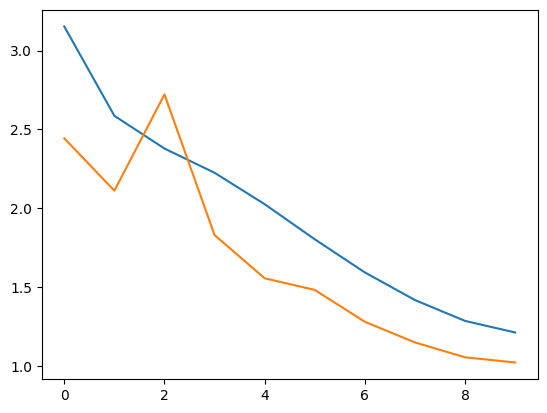

In [68]:
plt.plot([3.1535026460047573,
  2.5865359394751546,
  2.3787033878019095,
  2.2246889790610584,
  2.0253276157257196,
  1.8024325142126254,
  1.5920932110008377,
  1.41680481549724,
  1.2844385870582307,
  1.2109057284377116])
plt.plot([2.443525631216508,
  2.1108817601505714,
  2.7222233150578754,
  1.8293652791011183,
  1.5549695778496657,
  1.4811176031450681,
  1.278874765468549,
  1.147768812843516,
  1.0533701287040227,
  1.0205314106579069])

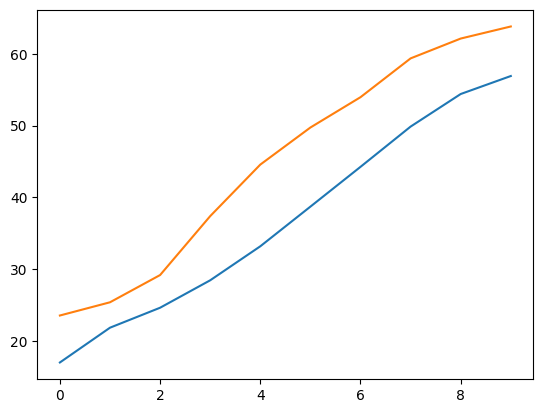

In [69]:
plt.plot([17.034,
  21.874,
  24.652,
  28.47,
  33.202,
  38.72,
  44.256,
  49.858,
  54.392,
  56.896])
plt.plot([23.57, 25.41, 29.2, 37.4, 44.57, 49.73, 53.95, 59.35, 62.11, 63.79])

In [70]:
main(dct, num_epochs)


Epoch 1/10
------------------------------------------------------------
Epoch [1/10] Batch [0/391] Loss: 2.4265 Acc: 10.94%
Epoch [1/10] Batch [50/391] Loss: 3.4365 Acc: 13.48%
Epoch [1/10] Batch [100/391] Loss: 2.9932 Acc: 15.14%
Epoch [1/10] Batch [150/391] Loss: 2.5704 Acc: 15.30%
Epoch [1/10] Batch [200/391] Loss: 2.9540 Acc: 15.94%
Epoch [1/10] Batch [250/391] Loss: 2.1657 Acc: 16.20%
Epoch [1/10] Batch [300/391] Loss: 2.4275 Acc: 16.57%
Epoch [1/10] Batch [350/391] Loss: 4.0965 Acc: 16.95%
Train Loss: 3.1443 Acc: 17.07%
Val Loss: 2.4742 Acc: 23.16%
New best model saved with accuracy: 23.16%

Epoch 2/10
------------------------------------------------------------
Epoch [2/10] Batch [0/391] Loss: 2.3225 Acc: 17.19%
Epoch [2/10] Batch [50/391] Loss: 2.4979 Acc: 19.09%
Epoch [2/10] Batch [100/391] Loss: 2.0926 Acc: 19.19%
Epoch [2/10] Batch [150/391] Loss: 2.3083 Acc: 19.54%
Epoch [2/10] Batch [200/391] Loss: 2.6049 Acc: 20.11%
Epoch [2/10] Batch [250/391] Loss: 2.5140 Acc: 20.26%
E

KeyboardInterrupt: 

In [72]:
res = {'train_losses': {'base': [3.0648812168394515,
   2.5425919702900646,
   2.427366428058166,
   2.375272044745248,
   2.3325978764487654,
   2.3192180001827154,
   2.263234903135568,
   2.150118954651191,
   2.0251116130663003,
   1.9514358327211931],
  'a2': [1.8777842210686726,
   1.5649149125189428,
   1.4574487489812515,
   1.3797237324287823,
   1.3198892936072386,
   1.2779439105402173,
   1.2533690090984335,
   1.2326754734034429,
   1.2249458275182779,
   1.2214272417070922],
  'a3': [1.5760477394094248,
   1.2549056604390254,
   1.1132861918500623,
   1.0163301735582864,
   0.9468476607671479,
   0.8958435834521223,
   0.8476135579826277,
   0.8184934035896341,
   0.7900377234534535,
   0.7827915913613556],
  'a4': [1.9396764567441038,
   1.6638948652140624,
   1.5388495086708947,
   1.465343436316761,
   1.4113732472709988,
   1.372176117909229,
   1.350701099771368,
   1.3265482510447197,
   1.316020062817332,
   1.310978644339325],
  'n4': [2.6859119136620055,
   2.2387167303763387,
   2.294932198036662,
   2.3375485562302574,
   2.200730265558833,
   2.052286114534149,
   1.9248806396713647,
   1.7585157210869558,
   1.6457188047106615,
   1.5861880837194144],
  'n3': [2.479458918047073,
   2.154904685666799,
   1.9251441001282323,
   2.015284330338773,
   1.8349593194854228,
   1.6315623390705078,
   1.4467847716168065,
   1.319445030463626,
   1.2215583647608452,
   1.1762699743975764],
  'n2': [9.1278620638201,
   2.323335665266227,
   2.30968545525885,
   2.304919851405541,
   2.303420418668586,
   2.302953229230993,
   2.3027786537814325,
   2.302713508191316,
   2.3026823729200436,
   2.3026668537608193]},
 'train_accs': {'base': [16.274,
   20.88,
   14.608,
   13.656,
   13.152,
   13.006,
   16.178,
   21.404,
   26.052,
   28.516],
  'a2': [31.18,
   42.466,
   46.658,
   49.914,
   52.356,
   53.944,
   54.956,
   55.818,
   56.058,
   56.13],
  'a3': [42.1,
   54.646,
   60.01,
   63.76,
   66.33,
   68.224,
   69.944,
   71.122,
   72.164,
   72.278],
  'a4': [28.922,
   39.008,
   43.37,
   46.49,
   48.544,
   50.246,
   51.328,
   52.172,
   52.458,
   52.596],
  'n4': [18.898,
   24.008,
   19.97,
   18.354,
   22.752,
   27.372,
   32.032,
   37.016,
   41.748,
   43.738],
  'n3': [21.628,
   26.164,
   33.01,
   33.008,
   38.12,
   43.926,
   49.436,
   54.182,
   57.524,
   59.14],
  'n2': [9.696, 9.894, 9.804, 9.852, 9.972, 9.74, 9.93, 9.85, 9.922, 10.0]},
 'val_losses': {'base': [2.1180824509149865,
   2.2149662941317017,
   2.169406088092659,
   2.144108888469165,
   2.251781285563602,
   2.2233726978302,
   2.103767099259775,
   1.9839648083795476,
   1.8756735385218752,
   1.8118064629880688],
  'a2': [1.5615381258952468,
   1.3818691516224342,
   1.298658247235455,
   1.2285845581489274,
   1.182045947147321,
   1.1497866435895991,
   1.1269201206255564,
   1.1139304698268069,
   1.1096151418323759,
   1.0994169349911846],
  'a3': [1.2050989730448662,
   1.1073719014095356,
   0.9584242867518075,
   0.8853317559519901,
   0.8669197325465046,
   0.7769223029100443,
   0.7408113939852654,
   0.7207947969436646,
   0.7016129380540003,
   0.6902058818672276],
  'a4': [1.6829462262648571,
   1.507546910756751,
   1.3859430053566075,
   1.3362040580073489,
   1.2943684164481828,
   1.2391042513183401,
   1.2240232380130622,
   1.206343572350997,
   1.1989622795129125,
   1.1971436014658288],
  'n4': [2.2520438930656335,
   2.3786443064484417,
   2.1225559801995,
   2.0325853734076778,
   1.9598840309094778,
   1.9323865145067625,
   1.6926490913463543,
   1.5838819696933408,
   1.5271625805504714,
   1.4806768637669236],
  'n3': [1.834889980811107,
   1.7712650133084646,
   1.9088250745700885,
   1.9008433517021468,
   1.661723342122911,
   1.3951440793049485,
   1.2827686539179162,
   1.1451554947261569,
   1.0806533950793593,
   1.0630070204976239],
  'n2': [2.3341270006155668,
   2.3135701040678387,
   2.306007964701592,
   2.3036465373220323,
   2.302944177313696,
   2.3027316769467125,
   2.302659891828706,
   2.3026322926147076,
   2.3026229037514216,
   2.3026203928114493]},
 'val_accs': {'base': [23.75,
   18.5,
   17.94,
   17.62,
   13.79,
   14.77,
   23.18,
   25.38,
   31.52,
   33.61],
  'a2': [44.74, 50.39, 53.43, 56.18, 58.1, 58.68, 59.75, 60.32, 60.35, 60.68],
  'a3': [56.8, 60.29, 66.25, 68.91, 69.57, 72.47, 73.41, 74.28, 75.53, 75.77],
  'a4': [39.69, 45.57, 49.99, 52.1, 53.29, 56.27, 56.97, 57.42, 57.94, 57.9],
  'n4': [24.63, 19.6, 20.0, 21.9, 26.86, 29.32, 39.0, 42.92, 47.63, 48.51],
  'n3': [31.86, 34.5, 37.16, 35.99, 43.64, 51.74, 55.12, 59.73, 62.09, 62.73],
  'n2': [10.0, 10.0, 10.0, 10.0, 9.99, 10.0, 10.0, 10.0, 10.0, 10.0]}}

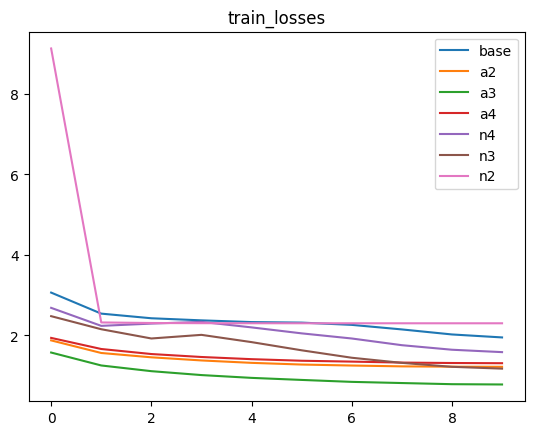

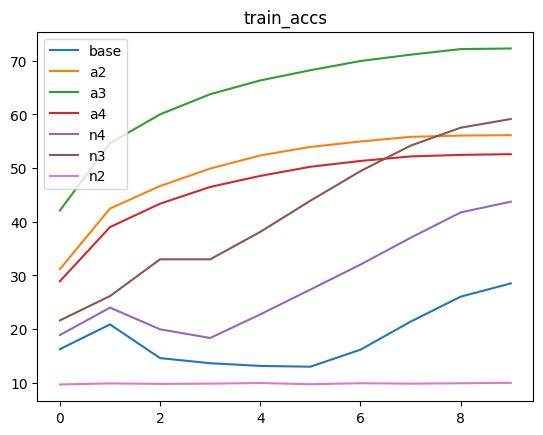

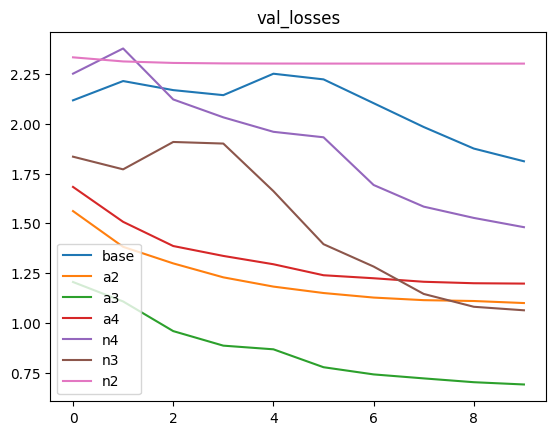

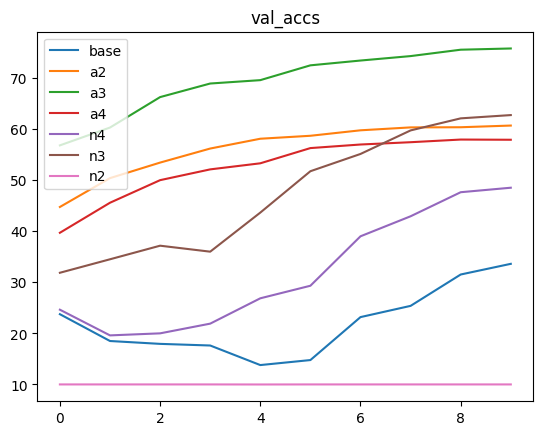

In [73]:
for title, d in res.items():
    plt.title(title)
    draw(d)
    plt.show()